# Turning Panels into Cross-Sections - Rolling-Transformation DiD (Lee & Wooldridge)

Most staggered-DiD estimators work around the two-way fixed effects (TWFE)
regression's failures. **LWDiD** (Lee & Wooldridge 2025, 2026) instead removes
the panel structure *before* estimation: a **rolling transformation** subtracts
each unit's own pre-treatment mean (or fitted pre-treatment trend) from its
post-treatment outcomes, turning the panel into cross-sectional estimation
problems - a single collapsed cross-section under common timing (and on the
staggered composite route), a sequence of cohort-by-calendar-time
cross-sections under staggered adoption. On each cross-section,
treatment-effect estimation is a standard exercise - any estimator applies
(regression adjustment, IPW, doubly robust IPWRA, matching), and none of
TWFE's negative-weighting or "forbidden comparison" pathologies can arise.

The papers contribute two further results we will use throughout:

- **Exact small-sample inference** (LW 2026): with independent sampling
  across units and homoskedastic normal cross-sectional errors, the ATT
  t-statistic follows an exact Student-t distribution - valid even with a
  *single treated unit*.
- **Staggered adoption** (LW 2025 Procedure 4.1/5.1; LW 2026 Section 7):
  cohort-specific transformations yield cohort effects, event-study effects
  WATT(r), and an overall aggregate.

This tutorial builds the method from the ground up, then replicates the papers'
two empirical applications on the authors' own datasets:

1. Why TWFE fails on staggered adoption - and how LWDiD avoids it
2. Demeaning (Procedure 2.1) and exact small-sample inference
3. Detrending (Procedure 3.1) for heterogeneous unit trends
4. **California Proposition 99** (common timing, one treated unit)
5. **Walmart entry and county retail employment** (staggered, 1,277 counties)
6. Cluster-robust and wild-bootstrap inference
7. Transformation diagnostics


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from diff_diff import BaconDecomposition, LWDiD
from diff_diff.datasets import load_prop99, load_walmart
from diff_diff.lwdid_visualization import plot_event_study

pd.set_option("display.precision", 4)


## 1. Why TWFE Fails - and What LWDiD Does Instead

We start with a synthetic staggered panel engineered to break TWFE: three
groups of units (never treated, adopting at $t=4$, adopting at $t=8$), with
treatment effects that **grow with time since treatment** and are stronger for
the early cohort. Both features are ubiquitous in applications, and together
they are exactly the configuration where the static TWFE coefficient becomes a
badly weighted average (Goodman-Bacon 2021).

The true cohort-average effects in this design are **3.90** (early cohort) and
**1.80** (late cohort); weighting cohorts by their unit counts gives a true
overall effect of **2.87**.


In [2]:
rng = np.random.default_rng(42)
rows = []
for u in range(80):
    g = [0, 4, 8][u % 3]  # never treated / early adopter / late adopter
    alpha = rng.normal(0, 2)  # unit fixed effect
    for t in range(1, 13):
        d = int(g > 0 and t >= g)
        # effect grows with time since treatment; early cohort 1.5x stronger
        tau = d * (1.0 + 0.4 * (t - g)) * (1.5 if g == 4 else 1.0)
        rows.append(dict(unit=u, period=t, treated=d, first_treat=g,
                         outcome=alpha + 0.3 * t + tau + rng.normal(0, 0.5)))
syn = pd.DataFrame(rows)

# true estimands implied by the DGP
e_early = np.mean([1.5 * (1 + 0.4 * (t - 4)) for t in range(4, 13)])
e_late = np.mean([1.0 * (1 + 0.4 * (t - 8)) for t in range(8, 13)])
print(f"true cohort effects: early {e_early:.3f}, late {e_late:.3f}")
print(f"true overall (cohort-size weighted): {(27 * e_early + 26 * e_late) / 53:.3f}")


true cohort effects: early 3.900, late 1.800
true overall (cohort-size weighted): 2.870


The Goodman-Bacon decomposition computes the static TWFE estimate and breaks
it into its constituent 2x2 comparisons. Watch the `later_vs_earlier` rows:
those comparisons use *already-treated* units as controls, and because their
effects are still growing, the comparison is contaminated.


In [3]:
bacon = BaconDecomposition().fit(syn, outcome="outcome", unit="unit",
                                 time="period", first_treat="first_treat")
print(f"static TWFE estimate: {bacon.twfe_estimate:.3f}   (truth: 2.870)\n")
weights = bacon.weight_by_type()
effects = bacon.effect_by_type()
for kind in weights:
    eff = effects[kind]
    eff_s = f"{eff:8.3f}" if eff is not None else "     n/a"
    print(f"{kind:20s} weight {weights[kind]:6.1%}   avg 2x2 effect {eff_s}")


static TWFE estimate: 2.001   (truth: 2.870)

treated_vs_never     weight  66.3%   avg 2x2 effect    2.794
earlier_vs_later     weight  12.6%   avg 2x2 effect    2.617
later_vs_earlier     weight  21.0%   avg 2x2 effect   -0.865


TWFE lands at **2.00** - a 30% understatement - because 21% of its weight sits
on later-vs-earlier comparisons whose average 2x2 effect is **negative**
(-0.87): the early cohort's still-growing effects are differenced *out of* the
late cohort's estimate.

LWDiD sidesteps the problem. For each cohort $g$ it demeans outcomes against
that cohort's own pre-$g$ periods, then estimates each post-period effect from
a clean cross-section of cohort-$g$ units versus not-yet-treated or
never-treated controls. No already-treated unit is ever used as a control.


In [4]:
lw_syn = LWDiD(rolling="demean").fit(
    syn, outcome="outcome", unit="unit", time="period",
    treatment="treated", first_treat="first_treat")
print(f"LWDiD overall ATT: {lw_syn.att:.3f} (SE {lw_syn.se:.3f})   (truth: 2.870)")
for g, eff in sorted(lw_syn.cohort_effects.items()):
    print(f"  cohort g={g}: {eff['att']:.3f}   "
          f"(truth: {e_early if g == 4 else e_late:.3f})")


LWDiD overall ATT: 2.953 (SE 0.060)   (truth: 2.870)
  cohort g=4: 4.019   (truth: 3.900)
  cohort g=8: 1.845   (truth: 1.800)


LWDiD recovers **2.95** overall and **4.02 / 1.85** by cohort - each within
sampling noise of the truth, where TWFE was off by 30%.

> **Aggregation conventions.** Under the default
> `control_group="not_yet_treated"` pool used here, the overall `.att` is
> the cohort-mass-weighted aggregate of the cohort effects, and
> `cohort_effects` weights each cohort's estimable $(g, t)$ cells by their
> contributing treated mass. (In the never-treated regression-adjustment
> configuration - `control_group="never_treated"`, no covariates, plain
> `demean`/`detrend` - and with no complete-case drops, `.att` instead
> comes from the LW 2026 eq. 7.18 $\tau_\omega$ composite regression.)
> Every convention - and where they can differ on unbalanced panels - is
> documented in the methodology registry.

## 2. Demeaning (Procedure 2.1) and Exact Small-Sample Inference

The common-timing transformation is one line of algebra. With treatment
starting at period $S$, replace each post-period outcome by

$$\dot{Y}_{it} = Y_{it} - \bar{Y}_{i,\text{pre}}, \qquad t = S, \ldots, T$$

where $\bar{Y}_{i,\text{pre}}$ is unit $i$'s own pre-treatment mean
(Equation 2.12, LW 2026). Unit fixed effects cancel exactly, and under the
common-timing identification stack - no anticipation (NAC), conditional
parallel trends (CPTC), and overlap (OVLC), all LW 2025 - the ATT is the
coefficient on the treatment dummy in a cross-sectional regression of the
post-period average of $\dot{Y}_{it}$ on $D_i$.

Because that regression is an ordinary small cross-section, classical OLS
inference is **exact** under the classical model: *independent sampling
across units* plus homoskedastic normal errors make the t-statistic exactly
$\mathcal{T}_{N-2}$ (no covariates; $\mathcal{T}_{N-K-2}$ and
$\mathcal{T}_{N-2K-2}$ for the covariate designs). Cross-unit dependence
breaks the unclustered exact result - that is the assignment-level
clustering problem Section 6 handles. Here is a deliberately tiny panel -
12 units, 4 treated, true effect 2.0 - where asymptotic inference would be
indefensible:


In [5]:
rng = np.random.default_rng(7)
rows = []
for u in range(12):
    treated_u = int(u < 4)
    alpha = rng.normal(0, 3)  # large unit fixed effects
    for t in range(1, 9):
        d = treated_u * int(t >= 6)
        rows.append(dict(unit=u, period=t, treated=d,
                         outcome=alpha + 0.5 * t + 2.0 * d + rng.normal(0, 0.6)))
small = pd.DataFrame(rows)

lw_small = LWDiD(rolling="demean", vcov_type="classical").fit(
    small, outcome="outcome", unit="unit", time="period", treatment="treated")
print(f"ATT: {lw_small.att:.3f} (SE {lw_small.se:.3f})   truth: 2.0")
print(f"exact t inference: df = {lw_small.df_inference}, "
      f"p = {lw_small.p_value:.4f}")
print(f"95% CI: [{lw_small.conf_int[0]:.3f}, {lw_small.conf_int[1]:.3f}]")


ATT: 2.315 (SE 0.212)   truth: 2.0
exact t inference: df = 10, p = 0.0000
95% CI: [1.843, 2.786]


With $N = 12$ collapsed observations the ATT is estimated at **2.32
(SE 0.21)** with an exact $\mathcal{T}_{10}$ reference distribution, and the
95% interval **[1.84, 2.79]** covers the truth. The exactness is conditional
on homoskedastic normality of the *cross-sectional* error. Randomization
inference (Section 4) offers a complementary analysis that replaces those
assumptions with an assignment-based justification - it does not test them.

## 3. Detrending (Procedure 3.1) - When Units Drift Apart

Demeaning removes unit *levels*, but parallel trends fails when untreated
mean trends differ *systematically by treatment status or cohort* -
unit-slope heterogeneity that is unrelated to treatment is harmless. LW 2025
(Section 5) covers the systematic case with Assumption CHT (conditional
heterogeneous trends): fit each unit's own linear trend on its
pre-treatment periods, and subtract the *extrapolated* trend from the
post-treatment outcomes.

The next panel deliberately ties mean slope to treatment group: treated
units drift upward at 0.6 per period versus 0.2 for controls - a drift
difference not caused by treatment, whose true effect is **1.0**:


In [6]:
rng = np.random.default_rng(11)
rows = []
for u in range(40):
    treated_u = int(u < 15)
    alpha = rng.normal(0, 2)
    slope = 0.6 if treated_u else 0.2  # differential drift (not caused by treatment)
    for t in range(1, 13):
        d = treated_u * int(t >= 9)
        rows.append(dict(unit=u, period=t, treated=d,
                         outcome=alpha + slope * t + 1.0 * d + rng.normal(0, 0.5)))
trendy = pd.DataFrame(rows)

for rolling in ("demean", "detrend"):
    fit = LWDiD(rolling=rolling).fit(trendy, outcome="outcome", unit="unit",
                                     time="period", treatment="treated")
    print(f"{rolling:8s}: ATT {fit.att:.3f} (SE {fit.se:.3f})   truth: 1.0")


demean  : ATT 3.376 (SE 0.099)   truth: 1.0
detrend : ATT 1.098 (SE 0.202)   truth: 1.0


Demeaning reports **3.38** - more than triple the true effect - because the
treated units' faster drift is misattributed to treatment. Detrending recovers
**1.10**. The price of detrending is efficiency: each unit's intercept and slope are
nuisance parameters estimated from its own pre-period history, and
extrapolating the fitted trend forward amplifies that estimation noise (under
the classical inference conditions of Section 2, the collapsed regression's
exact-t degrees of freedom are unchanged). The practical workflow is to run
both and treat a large gap as *sensitivity to the trend specification* - a
prompt to think hard about which assumption (CPTC or CHT) is defensible - not
as a test that unit-specific trends exist.

## 4. California Proposition 99 - Common Timing, One Treated Unit

The first empirical application in LW 2026 (Section 6) is the classic
Abadie-Diamond-Hainmueller smoking panel: California passes Proposition 99 in
1989, raising the cigarette tax; the outcome is log per-capita cigarette
sales; the donor pool is 38 states that passed no comparable program. One
treated unit, common timing - the configuration where exact small-sample
inference earns its keep.

`load_prop99()` downloads the authors' own SSC ancillary dataset
(checksum-verified; if the download fails it falls back to a clearly marked
synthetic frame, so check `df.attrs["source"]` before interpreting numbers).


In [7]:
prop99 = load_prop99()
# fail closed: the replication prose below is only valid on the real data
assert prop99.attrs["source"] == "lwdid_ssc_ancillary", prop99.attrs["source"]
print(f"source: {prop99.attrs['source']}")
print(f"{prop99['state'].nunique()} states x {prop99['year'].nunique()} years "
      f"({prop99['year'].min()}-{prop99['year'].max()})")

p99 = {}
for rolling in ("demean", "detrend"):
    p99[rolling] = LWDiD(rolling=rolling, vcov_type="classical").fit(
        prop99, outcome="lcigsale", unit="state", time="year",
        treatment="treated")
    fit = p99[rolling]
    print(f"{rolling:8s}: ATT {fit.att:.4f} (SE {fit.se:.4f})   "
          f"exact p = {fit.p_value:.4f} (df = {fit.df_inference})")


source: lwdid_ssc_ancillary
39 states x 31 years (1970-2000)
demean  : ATT -0.4222 (SE 0.1208)   exact p = 0.0012 (df = 37)
detrend : ATT -0.2270 (SE 0.0941)   exact p = 0.0209 (df = 37)


This reproduces LW 2026 Table 3 exactly: demeaning gives **-0.422 (SE
0.121)**; detrending gives **-0.227 (SE 0.094)** with an exact
$\mathcal{T}_{37}$ p-value of **0.021**. The two transformations disagree by
nearly a factor of two - the demean-vs-detrend gap from Section 3, on real
data. California's cigarette sales were already declining faster than the
donor states' before 1989, so the detrended estimate (about a 20% reduction in
per-capita sales) is the defensible one, and it is *conditional on* the
detrending assumption CHT plus the design assumptions - the exact p-value
tests the treatment-effect null under those assumptions, not the assumptions
themselves.

The per-period trajectory shows the effect building over time, as a tax should:


tau(1989, r=0): -0.0423 (SE 0.0593)
tau(2000, r=11): -0.4029 (SE 0.1525)


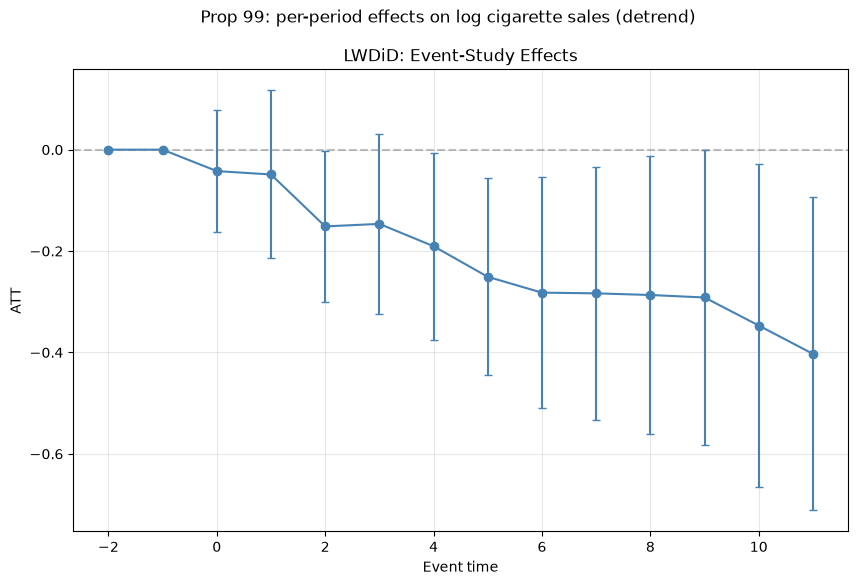

In [8]:
det = p99["detrend"]
es = det.event_study_effects
first, last = min(es), max(es)
print(f"tau(1989, r={first}): {es[first]['effect']:.4f} (SE {es[first]['se']:.4f})")
print(f"tau(2000, r={last}): {es[last]['effect']:.4f} (SE {es[last]['se']:.4f})")
fig = plot_event_study(det)
fig.suptitle("Prop 99: per-period effects on log cigarette sales (detrend)")
plt.show()


The effect grows from **-0.04 (SE 0.06)** in 1989 - indistinguishable from
zero on impact - to **-0.40 (SE 0.15)** by 2000.

### Randomization inference

Exact-t inference leans on conditional normality and homoskedasticity.
Randomization inference (RI) is the complementary check: re-randomize which
state is "California" across the 39 states, recompute the ATT each time, and
ask how extreme the real estimate is in that distribution. RI tests
**Fisher's sharp null** - no treatment effect for *any* unit, a stronger
hypothesis than a zero average effect under heterogeneity - and does not
require normality: its justification is conditional on the
complete-randomization assignment mechanism. `randomization_test()` replays
the *fitted* collapsed cross-section, so the statistic being permuted is
exactly the estimate above.


In [9]:
ri = det.randomization_test(n_reps=9999, seed=42)
print(f"randomization inference p-value: {ri.pvalue:.4f}")


randomization inference p-value: 0.0540


RI gives **p = 0.054** - close to the exact-t 0.021 in substance but not
identical: the procedures test *different nulls* (exact-t: zero average
effect under the classical model; RI: the sharp null of no effect for any
unit) under different assumptions, so neither validates the other. Two
conventions worth knowing:

- The implementation follows the authors' Stata package (`lwdid`): inclusive
  Phipson-Smyth counting, $p = (c + 1)/(B + 1)$, converging to about 0.051 at
  100,000 replications on this application.
- The *paper's* printed RI p-value of 0.020 is not reproducible with the
  authors' own package; the methodology registry records it as an as-printed
  discrepancy, and this library anchors to the package convention.

## 5. Walmart Entry and Retail Employment - Staggered Adoption

The second application (LW 2025, Section 6 and Appendix F) is genuinely
staggered: Walmart opens its first store in different counties in different
years, 1986 through 1999. The outcome is log county retail employment. We fit
the staggered design exactly as observed - each county's true first-entry year
is its cohort, and the 391 never-treated counties anchor the control pool.


In [10]:
walmart = load_walmart()
assert walmart.attrs["source"] == "lwdid_ssc_ancillary", walmart.attrs["source"]
print(f"source: {walmart.attrs['source']}")
cohorts = sorted(walmart.loc[walmart["first_year"] > 0, "first_year"].unique())
n_never = walmart.loc[walmart["first_year"] == 0, "cid"].nunique()
print(f"{walmart['cid'].nunique()} counties x {walmart['year'].nunique()} years; "
      f"{len(cohorts)} cohorts ({cohorts[0]}-{cohorts[-1]}); "
      f"{n_never} never-treated")

wm = LWDiD(rolling="detrend").fit(
    walmart, outcome="log_retail_emp", unit="cid", time="year",
    treatment="treated", first_treat="first_year")
print(f"\noverall ATT: {wm.att:.4f} (SE {wm.se:.4f})")


source: lwdid_ssc_ancillary
1277 counties x 23 years; 14 cohorts (1986-1999); 391 never-treated



overall ATT: 0.0199 (SE 0.0090)


County-level linear trends are critical in this application (the reason LW
use detrending as the headline specification), and the event-study surface is
where the results live. WATT($r$) is the average effect $r$ years from first
entry, weighting each cohort's contribution by its treated mass:


WATT(0):  0.0072 (SE 0.0037)
WATT(1):  0.0322 (SE 0.0051)
WATT(5):  0.0164 (SE 0.0109)
near leads (r = -7..-3):  max |WATT(r)| = 0.0059
all leads (r = -22..-3):  max |WATT(r)| = 0.0329 (at r = -22)


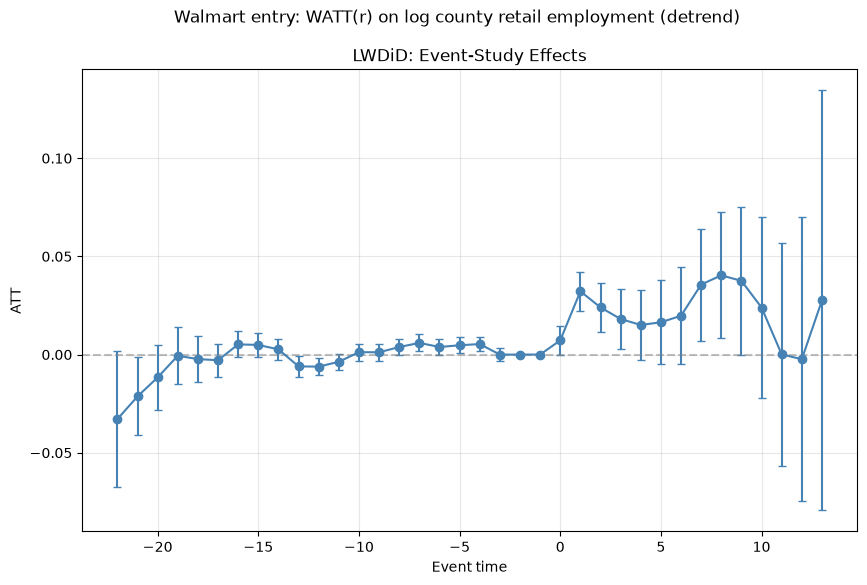

In [11]:
wes = wm.event_study_effects
print(f"WATT(0):  {wes[0]['effect']:.4f} (SE {wes[0]['se']:.4f})")
print(f"WATT(1):  {wes[1]['effect']:.4f} (SE {wes[1]['se']:.4f})")
print(f"WATT(5):  {wes[5]['effect']:.4f} (SE {wes[5]['se']:.4f})")
pre = {r: wes[r]["effect"] for r in sorted(wes) if r < -2}
near = {r: v for r, v in pre.items() if r >= -7}
print(f"near leads (r = -7..-3):  max |WATT(r)| = "
      f"{max(abs(v) for v in near.values()):.4f}")
print(f"all leads (r = -22..-3):  max |WATT(r)| = "
      f"{max(abs(v) for v in pre.values()):.4f} "
      f"(at r = {min(pre, key=lambda r: -abs(pre[r]))})")
fig = plot_event_study(wm)
fig.suptitle("Walmart entry: WATT(r) on log county retail employment (detrend)")
plt.show()


This reproduces the paper's Appendix Table A4 point estimates (rolling RA,
detrended; the displayed SEs use the library's analytical HC1 default, where
the paper's come from the Algorithm 1 multiplier bootstrap): one year after
entry, county retail employment is **3.2% higher** (WATT(1) = 0.032, SE
0.005) - under conditional no anticipation (CNAS), heterogeneous linear
trends (CHT), and overlap for the comparison pool (OVLS). The
placebo leads nearest treatment ($r = -7$ to $-3$) - where all 14 cohorts
contribute - stay below **0.006** in absolute value; the most distant leads
grow to **0.033** at $r = -22$, a cell only the 1999 cohort can reach (the
panel starts in 1977). The placebo transformations are evaluated within each
cohort's pre-treatment fit window, so far leads are legitimate placebo
evidence - but read them against their cohort support and uncertainty: a
single-cohort cell is far noisier than the fully supported near window. The
effect on impact ($r=0$,
typically a partial year of operation) is a smaller 0.007. The paper notes
the detrended 3.2% is consistent with Basker's (2005) estimate of 150-300
new retail jobs per store, where estimators that ignore county trends report
substantially larger effects.

## 6. Cluster-Robust and Wild-Bootstrap Inference

When treatment is assigned at a coarser level than the unit - regions, school
districts, retail chains - inference must cluster at the assignment level, and
with few clusters even the cluster-robust $t_{G-1}$ reference is strained.
LWDiD composes with the standard toolkit: `cluster=` switches the collapsed
cross-section to CR1 standard errors with a $G - 1$ reference distribution,
and `wild_cluster_bootstrap()` replays the fitted design through the wild
cluster restricted bootstrap (Rademacher weights, test inversion - matched to
R's `fwildclusterboot`).

The post-fit replay methods - `wild_cluster_bootstrap()` and
`randomization_test()` - are defined for *common-timing*
`estimation_method="reg"` fits (the bootstrap additionally requires a
`cluster=` fit); they replay the fitted collapsed cross-section, which
staggered results objects do not carry. Staggered fits keep analytical
clustered inference and the estimator's own multiplier bootstrap instead.


In [12]:
rng = np.random.default_rng(5)
rows = []
region_post_shock = rng.normal(0, 0.4, 12)  # region-wide POST-period shock
for u in range(60):
    region = u % 12
    treated_u = int(region < 5)  # treatment assigned at REGION level
    alpha = rng.normal(0, 1.5)
    for t in range(1, 9):
        d = treated_u * int(t >= 6)
        # the shock hits every unit in the region in the post window, so it
        # SURVIVES demeaning and leaves genuinely correlated residuals
        shock = region_post_shock[region] * int(t >= 6)
        rows.append(dict(unit=u, region=region, period=t, treated=d,
                         outcome=alpha + 0.4 * t + 1.2 * d + shock
                         + rng.normal(0, 0.5)))
clustered = pd.DataFrame(rows)

naive = LWDiD(rolling="demean").fit(
    clustered, outcome="outcome", unit="unit", time="period",
    treatment="treated")
print(f"hc1, clustering ignored: ATT {naive.att:.3f} (SE {naive.se:.3f})")

lw_cl = LWDiD(rolling="demean", cluster="region").fit(
    clustered, outcome="outcome", unit="unit", time="period",
    treatment="treated")
print(f"region-clustered:        ATT {lw_cl.att:.3f} (CR1 SE {lw_cl.se:.3f}), "
      f"G = {lw_cl.n_clusters}   truth: 1.2")

wcb = lw_cl.wild_cluster_bootstrap(n_bootstrap=1999, seed=42)
print(f"wild cluster bootstrap: p = {wcb.p_value:.4f}, "
      f"95% CI [{wcb.ci_lower:.3f}, {wcb.ci_upper:.3f}]")


hc1, clustering ignored: ATT 1.048 (SE 0.131)
region-clustered:        ATT 1.048 (CR1 SE 0.237), G = 12   truth: 1.2
wild cluster bootstrap: p = 0.0025, 95% CI [0.503, 1.614]


Ignoring the assignment level understates the SE by almost half (**0.131**
vs the clustered **0.237**): the region-wide post-period shock is common to
every unit in a region, so unit-level residuals are not independent. With
only 12 clusters the cluster-asymptotic CR1 approximation (a $t_{G-1}$
reference) is itself strained, so the
wild-bootstrap CI **[0.50, 1.61]** is the preferred interval of the two; it
covers the truth of 1.2. (Twelve clusters is still few for any method -
with very few or unbalanced clusters, compare Rademacher against
`weight_type="webb"` as a sensitivity check.)

A note on the heteroskedasticity-robust ladder: `vcov_type` accepts
`"classical"`, `"hc1"`, `"hc2"`, and `"hc3"` for regression adjustment. HC3 is
the conservative small-sample choice *when leverage is bounded away from one*;
in single-treated-unit designs the treated observation has leverage exactly
one and HC3 is undefined (the library fails closed with NaN inference rather
than fabricating a number) - use exact classical-t or randomization inference
there, as in Section 4.

## 7. Transformation Diagnostics

Because every LWDiD estimate is built from per-unit pre-treatment fits, the
transformation itself is inspectable. `get_transformation_diagnostics()`
returns each unit's fitted pre-trend and fit quality without running the
estimator:


In [13]:
diag = LWDiD(rolling="detrend").get_transformation_diagnostics(
    prop99, outcome="lcigsale", unit="state", time="year", treatment="treated")
s = diag["summary"]
print(f"units: {s['n_units_valid']}/{s['n_units_total']} valid "
      f"({s['n_units_dropped']} dropped)")
print(f"pre-trend slopes: mean {s['mean_beta']:.4f}, sd {s['std_beta']:.4f}")
print(f"mean pre-period R^2: {s['mean_r_squared']:.3f}")

cols = ["alpha", "beta", "r_squared", "pre_n_periods"]
per_unit = pd.DataFrame(diag["per_unit"]).T[cols].astype(float)
per_unit.nlargest(5, "beta")


units: 39/39 valid (0 dropped)
pre-trend slopes: mean -0.0038, sd 0.0082
mean pre-period R^2: 0.251


,alpha,beta,r_squared,pre_n_periods
Tennessee,4.8014,0.0119,0.7006,19.0
Arkansas,4.7802,0.0116,0.6053,19.0
Alabama,4.7184,0.0097,0.4050,19.0
Georgia,4.8323,0.0063,0.4779,19.0
South Carolina,4.8547,0.0048,0.1311,19.0


All 39 states have valid pre-period fits, and the fitted slopes are small
(mean -0.004 log points per year, sd 0.008). These are *descriptive*
outputs, not assumption tests: a small average slope does not certify
parallel trends, and a low per-unit $R^2$ is not a failure of the method -
the papers note the unit-specific trend estimates need not individually be
precise for the estimator to work. Use the table for sensitivity work: units
with extreme fitted slopes are natural candidates for a *pre-specified*
leave-one-out check, reported alongside (never instead of) the full-sample
result.

## Summary

| Situation | Reach for |
|---|---|
| Staggered adoption, effects may vary by cohort/time | `LWDiD` with `first_treat=` (never uses already-treated controls) |
| Units on visibly different pre-trends | `rolling="detrend"` (Procedure 3.1/5.1); compare against `"demean"` |
| Tiny N, even one treated unit | `vcov_type="classical"` exact t (common-timing fits and the eligible never-treated $\tau_\omega$ composite, which keeps its own exact $\mathcal{T}_{n-2}$; multi-cell influence-function aggregates use a normal reference - see the registry); `randomization_test()` for Fisher's sharp null as the assignment-based alternative |
| Treatment assigned at group level, few groups | `cluster=` + `wild_cluster_bootstrap()` (post-fit replay: common-timing `reg` fits; staggered fits use analytical clustered inference / the multiplier bootstrap) |
| Covariates needed for parallel trends | `covariates=[...]` (unit-constant) with `estimation_method="reg"`, `"dr"`, or `"psm"` (PSM: point estimates only - matching-variance inference is deferred) |

Compared with its staggered-DiD siblings: `CallawaySantAnna` long-differences
against period $g-1$ only, while LWDiD's rolling transformation weights all
pre-treatment periods. The paper positions the two as complementary - neither
is uniformly more efficient (CS can win under strong positive serial
correlation, being closer to first-differencing), so it recommends trying
both; only LWDiD offers the unit-specific detrending arm. `WooldridgeDiD`
targets the same cohort-time ATTs through one saturated regression - rolling
RA is *numerically* equivalent to ETWFE under common timing and, in
staggered designs, at the impact cell only (calendar time $t = g$, event
time $r = 0$); later event times generally differ.
The methodology registry (`docs/methodology/REGISTRY.md`) documents every
convention used here - the $\tau_\omega$ composite, cell-mass cohort
weighting, the RI counting rule - with the papers' equation numbers.

**References**: Lee & Wooldridge (2025), *A Simple Transformation Approach
to Difference-in-Differences Estimation for Panel Data*
(https://ssrn.com/abstract=4516518); Lee & Wooldridge (2026), *Simple
Approaches to Inference with Difference-in-Differences Estimators with Small
Cross-Sectional Sample Sizes* (https://ssrn.com/abstract=5325686);
Goodman-Bacon (2021); Basker (2005).
